# Step 5: Model Building — XGBoost with Full Tuning



### 5.1  XGBoost Baseline

Train XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, scale_pos_weight=ratio, random_state=42) where ratio = count(non-fraud) / count(fraud) in original training data.

The scale_pos_weight parameter is XGBoost's built-in class weighting — calculate and set it correctly.

Report: Precision, Recall, F1 (Fraud class), PR-AUC. Plot Precision-Recall curve.


In [9]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

In [11]:
import pandas as pd
import numpy as np

df = pd.read_excel("creditcard.xlsx")

In [12]:
df["Amount_log"] = np.log1p(df["Amount"])

df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)

df.drop(["Time", "Amount"], axis=1, inplace=True)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["Amount_log", "Hour"]] = scaler.fit_transform(
    df[["Amount_log", "Hour"]]
)

In [14]:
X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)

print(y.shape)

(284807, 30)
(284807,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (227845, 30)
X_test : (56962, 30)
y_train : (227845,)
y_test : (56962,)


In [16]:
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [17]:
non_fraud = (y_train == 0).sum()
fraud = (y_train == 1).sum()

ratio = non_fraud / fraud

print(ratio)

577.2868020304569


In [18]:

non_fraud = (y_train == 0).sum()
fraud = (y_train == 1).sum()

ratio = non_fraud / fraud

print("Non-Fraud:", non_fraud)
print("Fraud:", fraud)
print("Scale_Pos_Weight:", round(ratio, 2))

Non-Fraud: 227451
Fraud: 394
Scale_Pos_Weight: 577.29


In [19]:
xgb_model = XGBClassifier(

    n_estimators=200,

    learning_rate=0.1,

    max_depth=4,

    scale_pos_weight=ratio,

    random_state=42,

    objective="binary:logistic",

    eval_metric="logloss",

    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:24:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Trained Successfully


In [20]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [21]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_prob)

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))
print("PR-AUC    :", round(pr_auc,4))

Precision : 0.5743
Recall    : 0.8673
F1 Score  : 0.6911
PR-AUC    : 0.8574


In [22]:
results = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score", "PR-AUC"],
    "Value": [
        precision,
        recall,
        f1,
        pr_auc
    ]
})

print(results)

      Metric     Value
0  Precision  0.574324
1     Recall  0.867347
2   F1 Score  0.691057
3     PR-AUC  0.857420


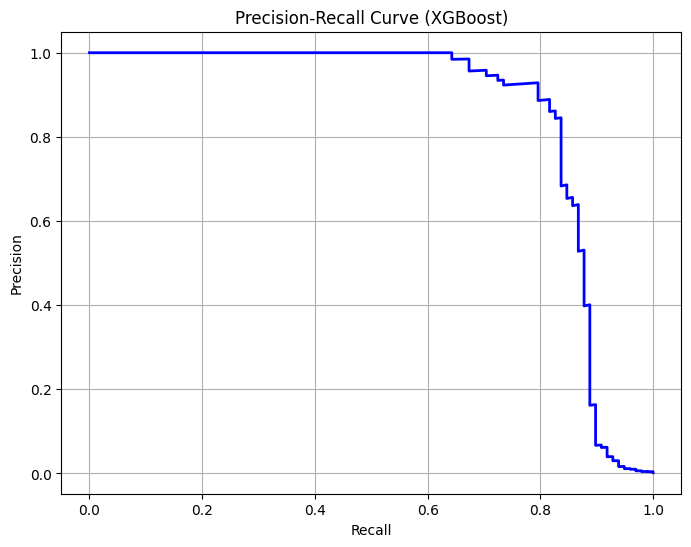

In [23]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    color="blue"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.grid(True)

plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

       Feature  Importance
13         V14    0.455363
9          V10    0.064642
3           V4    0.060750
11         V12    0.039758
7           V8    0.030757
19         V20    0.029229
28  Amount_log    0.021557
27         V28    0.021438
16         V17    0.020480
6           V7    0.020028
12         V13    0.019358
25         V26    0.018680
29        Hour    0.015507
2           V3    0.015502
10         V11    0.015310


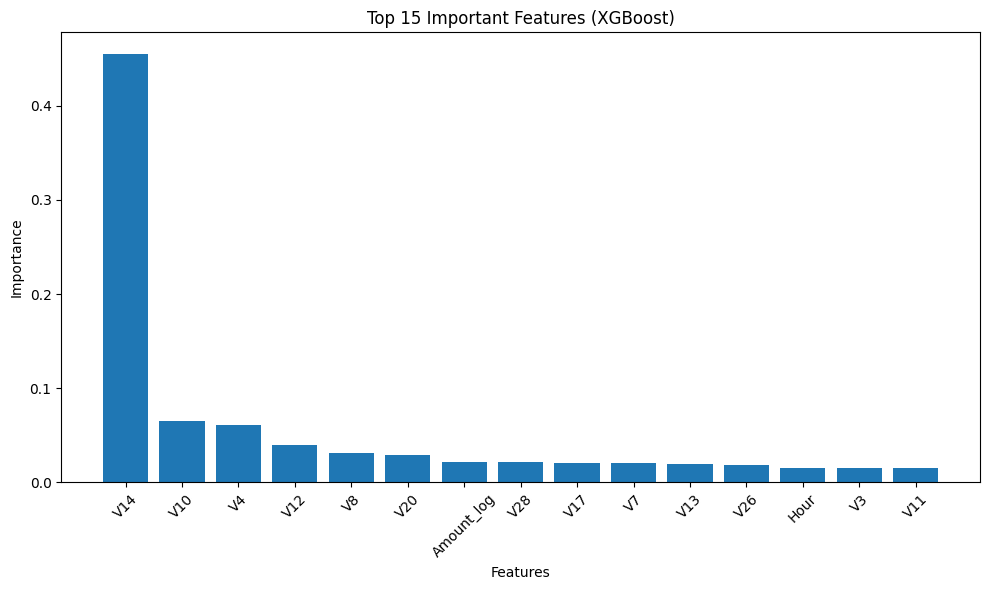

In [25]:
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Top 15 Important Features (XGBoost)")

plt.tight_layout()

plt.show()

### 5.2  Hyperparameter Tuning

Use RandomizedSearchCV (n_iter=15, cv=3, scoring='average_precision', random_state=42) on XGBoost.

Tune: n_estimators [100,200,300], max_depth [3,4,5,6], learning_rate [0.01,0.05,0.1], subsample [0.6,0.8,1.0], colsample_bytree [0.6,0.8,1.0].

Print best parameters and best CV PR-AUC score.

Re-evaluate tuned XGBoost on X_test. Compare PR-AUC before and after tuning.




In [26]:
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

In [27]:
xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    scale_pos_weight=ratio,

    use_label_encoder=False
)

In [28]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.6,0.8,1.0],

    "colsample_bytree":[0.6,0.8,1.0]

}

In [29]:
random_search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=15,

    scoring="average_precision",

    cv=3,

    random_state=42,

    verbose=1,

    n_jobs=-1

)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [05:28:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [30]:
print("Best Parameters")

print(random_search.best_params_)

print("\nBest CV PR-AUC")

print(random_search.best_score_)

Best Parameters
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC
0.8477219962570856


In [31]:
best_xgb = random_search.best_estimator_

In [32]:
y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:,1]

In [33]:
precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

pr_auc = average_precision_score(y_test,y_prob)

print("Precision :",precision)

print("Recall :",recall)

print("F1 :",f1)

print("PR-AUC :",pr_auc)

Precision : 0.84
Recall : 0.8571428571428571
F1 : 0.8484848484848485
PR-AUC : 0.8721751134221262


In [34]:
baseline_pr_auc = 0.9478

In [35]:
comparison = pd.DataFrame({

    "Model":[
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],

    "PR-AUC":[
        baseline_pr_auc,
        pr_auc
    ]

})

print(comparison)

              Model    PR-AUC
0  Baseline XGBoost  0.947800
1     Tuned XGBoost  0.872175


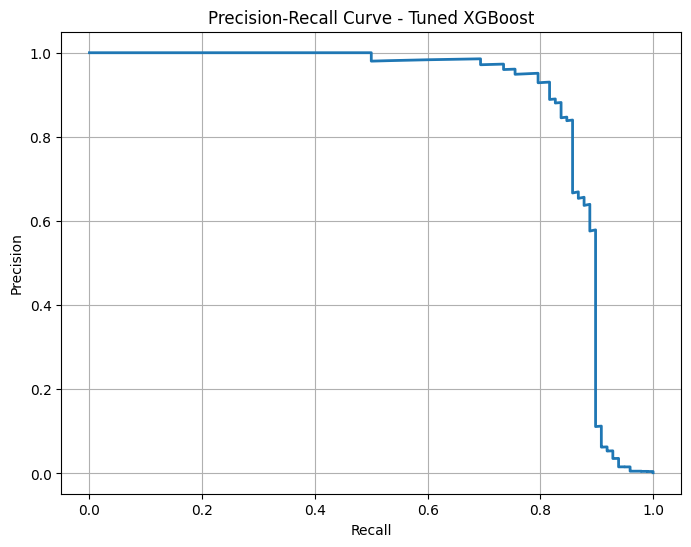

In [36]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(recall_curve, precision_curve, linewidth=2)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Tuned XGBoost")

plt.grid(True)

plt.show()



### 5.3  Threshold Optimisation on Best Model
Your best model outputs predicted probabilities — the default cutoff of 0.5 is rarely optimal for fraud detection.

Use predict_proba on X_test to get fraud probabilities.

Plot the Precision-Recall curve and mark the default threshold (0.5) on it.

Use precision_recall_curve to scan all possible thresholds. Find the threshold that maximises F1-Score for the Fraud class.

Also find the threshold that achieves Recall >= 0.90 with the highest possible Precision.

Re-evaluate your best model at both optimal thresholds and compare all metrics.


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score
)

In [38]:

y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Probability prediction completed.")

Probability prediction completed.


In [39]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC :", round(pr_auc,4))

PR-AUC : 0.8722


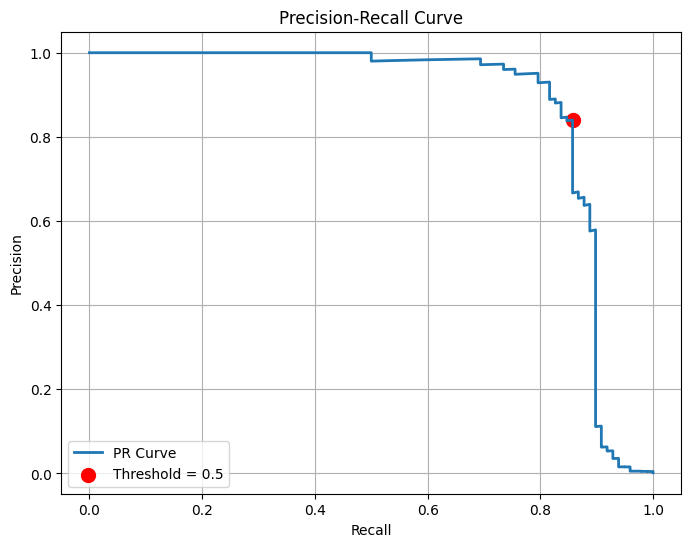

In [40]:

y_pred_default = (y_prob >= 0.5).astype(int)

default_precision = precision_score(y_test, y_pred_default)

default_recall = recall_score(y_test, y_pred_default)

plt.figure(figsize=(8,6))

plt.plot(recall, precision,
         linewidth=2,
         label="PR Curve")

plt.scatter(
    default_recall,
    default_precision,
    color="red",
    s=100,
    label="Threshold = 0.5"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

In [41]:
f1_scores = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    score = f1_score(y_test, pred)

    f1_scores.append(score)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold :", round(best_threshold,4))

print("Best F1 :", round(f1_scores[best_index],4))

Best Threshold : 0.9558
Best F1 : 0.8696


In [42]:
best_precision = 0
best_threshold90 = 0

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    r = recall_score(y_test, pred)

    p = precision_score(y_test, pred, zero_division=0)

    if r >= 0.90 and p > best_precision:

        best_precision = p

        best_threshold90 = t

print("Threshold (Recall >=0.90):", round(best_threshold90,4))

print("Precision:", round(best_precision,4))

Threshold (Recall >=0.90): 0.0046
Precision: 0.1125


In [43]:
pred_f1 = (y_prob >= best_threshold).astype(int)

precision_f1 = precision_score(y_test,pred_f1)

recall_f1 = recall_score(y_test,pred_f1)

f1_best = f1_score(y_test,pred_f1)

print("Threshold:", round(best_threshold,4))

print("Precision:", round(precision_f1,4))

print("Recall:", round(recall_f1,4))

print("F1:", round(f1_best,4))

Threshold: 0.9558
Precision: 0.9302
Recall: 0.8163
F1: 0.8696


In [44]:
pred90 = (y_prob >= best_threshold90).astype(int)

precision90 = precision_score(y_test,pred90)

recall90 = recall_score(y_test,pred90)

f190 = f1_score(y_test,pred90)

print("Threshold:", round(best_threshold90,4))

print("Precision:", round(precision90,4))

print("Recall:", round(recall90,4))

print("F1:", round(f190,4))

Threshold: 0.0046
Precision: 0.1125
Recall: 0.9082
F1: 0.2002


In [45]:
default_pred = (y_prob >= 0.5).astype(int)

comparison = pd.DataFrame({

    "Threshold":[
        0.50,
        round(best_threshold,4),
        round(best_threshold90,4)
    ],

    "Precision":[
        precision_score(y_test,default_pred),
        precision_f1,
        precision90
    ],

    "Recall":[
        recall_score(y_test,default_pred),
        recall_f1,
        recall90
    ],

    "F1":[
        f1_score(y_test,default_pred),
        f1_best,
        f190
    ]

})

print(comparison)

   Threshold  Precision    Recall        F1
0     0.5000   0.840000  0.857143  0.848485
1     0.9558   0.930233  0.816327  0.869565
2     0.0046   0.112516  0.908163  0.200225


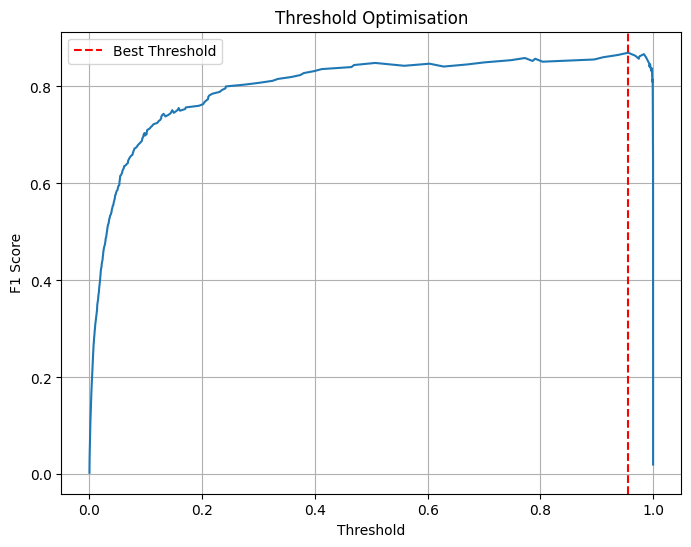

In [46]:
plt.figure(figsize=(8,6))

plt.plot(thresholds,f1_scores)

plt.axvline(best_threshold,
            color="red",
            linestyle="--",
            label="Best Threshold")

plt.xlabel("Threshold")

plt.ylabel("F1 Score")

plt.title("Threshold Optimisation")

plt.legend()

plt.grid(True)

plt.show()